# Deep Hedging, Bayesian Optimization, Training Algorithms and Randomness

Deep Hedging is an important instance of Machine Learning in Finance where a non-standard neural network is trained to learn the hedging actions of an informed trader. We shall focus in the sequel on one implementation of this artifcial trader and analyze the training algorithms behind.

#Deep Hedging

Deep Hedging goes back to the following [paper](https://arxiv.org/abs/1802.03042)  by Hans Bühler, Lukas Gonon, Josef Teichmann and Ben Wood.

The main idea is to parametrize the hedging strategies (at each time) via neural networks which can depend on input variables chosen by the user, for instance the current price, the past strategy, etc.
This then allows to solve a potentially high dimensional hedging problem for many assets whose dynamics are described by an arbitrary given arbitrage free model even in the presence of transaction costs.

Let us exemplify first the idea by the Black Scholes model in one dimension.

# Deep Hedging exemplified by means of the Black Scholes model

Let $T$ be a finite time horizon and consider on a filtered probability space $(\Omega, (\mathcal{F}_{0\leq t\leq T}), \mathcal{F}_T, P)$ a standard Black Scholes model with interest rate $r=0$ and the price of the risky asset $S$ being described by

$$
dS_t=S_t\mu dt + S_t\sigma dW^{\mathbb{P}}_t, \quad S_0=S_0
$$

under the physical measure $\mathbb{P}$. Here $\mu \geq 0$, $\sigma \neq 0$, $S_0 >0$ and $W^{\mathbb{P}}$ is a Brownian motion (under $\mathbb{P}$).

Under the unique risk neutral probability measure, denoted by $\mathbb{Q}$, the dynamics are then given by

$$
dS_t= S_t\sigma dW_t, \quad S_0=S_0
$$

where $W$ is a $\mathbb{Q}$ Brownian motion

We consider here the problem of hedging a $\mathcal{F}_T$-measurable claim $f(S_T)$. In the case of the Black Scholes model the hedging strategy can be found by the Delta hedge, i.e.

$$
\Delta(t,s)=\partial_s \mathbb{E}_{Q}[f(S_T)| S_t=s].
$$

In more involved models this is no longer possible. In particular in incomplete models not every claim can be hedged and we thus need to optimize a hedging criterion. We here consider a __quadratic hedging criterion__ but other risk measures are of course also possible.

Let $\pi$ denote the price of the option, i.e. $\mathbb{E}_Q[f(S_T)]$. Then the goal is solve the following optimization problem

$$
\inf_{H \text{ predictable }}\mathbb{E}[( f(S_T)- \pi- (H\bullet S)_T)^2],
$$

where $(H_t)$ ranges over all predictable process and $(H \bullet S)_T= \int_0^T H_t dS_t$ denotes the stochastic Ito integral. Optimizing over all predictable processes is infeasable.

Therefore we choose to specify $H_t$ in a smaller set: for each $t$ as a neural network whose input can be specified.  In complete Markovian models, as it is the case of the Black Scholes model, we know from the delta hedging strategy that it makes sense to parameterize $H_t$ as a function of the current price $S_t$.  In the current setting we therefore choose that the input of each neural network in the implementation below depends only on the current price, i.e.

$$
H_t=g_t(S_t)
$$

and $g_t$ denotes a neural network.

We can view the above as supervised learning problem: the input data $x_i$ correspond to trajectories of $(S_t(\omega_i))_{0 \leq T}$, the output $y_i$ should be $0$ and the
the loss function is given by

$$
\mathcal{L}=  \left(f(S_T(\omega_i))- \pi- \int_0^T g_t(S_t (\omega_i)) dS_t(\omega_i)\right)^2.
$$

To implement this we need to generate input data which will be our training data set. Consider the log price of $S_t$ under $\mathbb{Q}$, i.e.

$$
d\log(S_t)= -\frac{\sigma^2}{2} dt + \sigma dW_t.
$$

The practical implementation requires a time discretization.
If we discretize our time interval $[0,T]$ in $N$ time steps of length $T/N$ we can write

$$
\log(S_i)= \log(S_{i-1}) -\frac{\sigma^2}{2} \frac{T}{N} + \sigma \sqrt{\frac{T}{N}} Z_i, i=1, \ldots, N
$$

where $Z_i$ are independent $N(0,1)$ distributed random variables. The discretized price $(S_0, S_1, \ldots S_N)$ is obtained by exponentiation.

In this disretized form the whole trajetory of the price $(S_0, S_1, \ldots S_N)$ is therefore determined by $(S_0, Z_1, \ldots, Z_N)$ or in other words $(S_0, X_1, \ldots, X_N)$  where $X_i$ are independent  $N(-\frac{\sigma^2}{2} \frac{T}{N} ,\sigma^2 \frac{T}{N})$ distributed random variables. Considering $K$ many samples thereof constitutes the input training data set. The outputs are simply $K$ zeros.

In the above loss function we also need to disretize the
stochastic integral

$$
\int_0^T g_t(S_t (\omega)) dS_t(\omega).
$$

We do this by choosing $N$ neural networks $g_0, \ldots, g_{N-1}$ and disretizing the integral as follows:

$$
\sum_{i=0}^{N-1} g_i(S_i(\omega)) (S_{i+1}(\omega)-S_i(\omega)) \, .
$$


In contrast to the original deep hedging approach we consider two training data sets here (xtrain and xtrain_red), where the second one is not a random sample Ktrain trajectories, but rather a set of trajectories, where R initial steps coincide for sets of N_red trajectories.

In [ ]:
%tensorflow_version 1.x
import numpy as np
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Concatenate, Dropout, Subtract, \
                        Flatten, MaxPooling2D, Multiply, Lambda, Add, Dot
from keras.backend import constant
from keras import optimizers

from keras.engine.topology import Layer
from keras.models import Model
from keras.layers import Input
from keras import initializers
from keras.constraints import max_norm
import keras.backend as K

import matplotlib.pyplot as plt

import copy

In [ ]:
N=100 # time disrectization
S0=1 # initial value of the asset
T=1 # maturity
strike = 1.0
sigma=0.2 # volatility in Black Scholes

In [ ]:
import scipy.stats as scipy
from scipy.stats import norm

#Blackscholes price

def BS(S0, strike, T, sigma):
    return S0*scipy.norm.cdf((np.log(S0/strike)+0.5*T*sigma**2)/(np.sqrt(T)*sigma))-strike*scipy.norm.cdf((np.log(S0/strike)-0.5*T*sigma**2)/(np.sqrt(T)*sigma))

priceBS=BS(S0,strike,T,sigma)
print('Price of a Call option in the Black scholes model with initial price', S0, 'strike', strike, 'maturity', T , 'and volatility' , sigma, 'is equal to', BS(S0,strike,T,sigma))

Price of a Call option in the Black scholes model with initial price 1 strike 1.0 maturity 1 and volatility 0.2 is equal to 0.07965567455405798


In [ ]:
#Definition of neural networks for heding strategies

m = 1 # dimension of price
d = 3 # number of layers in strategy
n = 32  # nodes in the first but last layers

# architecture is the same for all networks
layers = []
for j in range(N):
    for i in range(d):
        if i < d-1:
            nodes = n
            layer = Dense(nodes, activation='tanh',trainable=True,
                      kernel_initializer=initializers.RandomNormal(0,1),#kernel_initializer='random_normal',
                      bias_initializer='random_normal',
                      name=str(i)+str(j))
        else:
            nodes = m
            layer = Dense(nodes, activation='linear', trainable=True,
                          kernel_initializer=initializers.RandomNormal(0,0.1),#kernel_initializer='random_normal',
                          bias_initializer='random_normal',
                          name=str(i)+str(j))
        layers = layers + [layer]

In [ ]:
#Implementing the loss function
# Inputs is the training set below, containing the price S0,
#the initial hedging being 0, and the increments of the log price process
price = Input(shape=(m,))
hedge = Input(shape=(m,))
hedgeeval = Input(shape=(m,))
premium = Input(shape=(m,))

inputs = [price]+[hedge]+[hedgeeval]+[premium]
outputhelper=[]

premium = Dense(m, activation='linear', trainable=True,
                kernel_initializer=initializers.RandomNormal(0,1),#kernel_initializer='random_normal',
                bias_initializer=initializers.RandomNormal(0,1))(premium)

for j in range(N):
    strategy = price
    strategyeval=hedgeeval
    for k in range(d):
        strategy= layers[k+(j)*d](strategy) # strategy at j is the hedging strategy at j , i.e. the neural network g_j
        strategyeval=layers[k+(j)*d](strategyeval)
    incr = Input(shape=(m,))
    logprice= Lambda(lambda x : K.log(x))(price)
    logprice = Add()([logprice, incr])
    pricenew=Lambda(lambda x : K.exp(x))(logprice)# creating the price at time j+1
    priceincr=Subtract()([pricenew, price])
    hedgenew = Multiply()([strategy, priceincr])
    #mult = Lambda(lambda x : K.sum(x,axis=1))(mult) # this is only used for m > 1
    hedge = Add()([hedge,hedgenew]) # building up the discretized stochastic integral
    inputs = inputs + [incr]
    outputhelper = outputhelper + [strategyeval]
    price=pricenew
payoff= Lambda(lambda x : 0.5*(K.abs(x-strike)+x-strike))(price)
outputs = Subtract()([payoff,hedge])
outputs = Subtract()([outputs,premium]) # payoff minus price minus hedge
outputs= [outputs] + outputhelper +[premium]
outputs = Concatenate()(outputs)

model_hedge_strat = Model(inputs=inputs, outputs=outputs)

In [ ]:
gamma = 1.0
grid = [(i/N)**gamma*T for i in range(N+1)]

Ktrain = 10**5
initialprice = S0

# xtrain consists of the price S0,
#the initial hedging being 0, and the increments of the log price process
xtrain = ([initialprice*np.ones((Ktrain,m))] +
          [np.zeros((Ktrain,m))]+
          [np.ones((Ktrain,m))] +
          [priceBS*np.ones((Ktrain,m))]+
          [np.random.normal(-(sigma)**2/2*(grid[i+1]-grid[i]),sigma*np.sqrt(grid[i+1]-grid[i]),(Ktrain,m)) for i in range(N)])

ytrain=np.zeros((Ktrain,1+N))

In [ ]:
#import keras
from keras import losses
def custom_loss(y_true,y_pred):
    #return losses.mean_squared_error(y_true[0], y_pred[0])
    z = y_pred[:,0]-y_true[:,0]
    z=K.mean(K.square(z))
    return z

In [ ]:
model_hedge_strat.compile(optimizer='adam',loss=custom_loss)


In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    model_hedge_strat.fit(x=xtrain,y=ytrain, epochs=1,verbose=True,batch_size=10000)

Epoch 1/1
100000/100000 [==============================] - 11s 110us/step - loss: 6.4868e-05
Epoch 1/1
100000/100000 [==============================] - 11s 111us/step - loss: 6.2362e-05
Epoch 1/1
100000/100000 [==============================] - 11s 109us/step - loss: 6.1327e-05
Epoch 1/1
100000/100000 [==============================] - 11s 110us/step - loss: 6.0965e-05
Epoch 1/1
100000/100000 [==============================] - 11s 110us/step - loss: 6.0839e-05


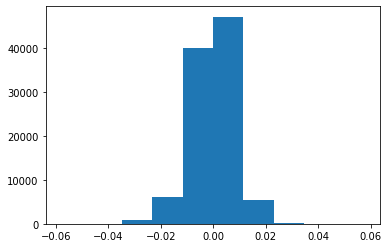

0.007859205
0.079651296


In [ ]:
a = model_hedge_strat.predict(xtrain)
plt.hist(a[:,0])
plt.show()
print(np.std(a[:,0]))
print(np.mean(a[:,N+1]))

In [ ]:
Ktest=50
xtest = ([initialprice*np.ones((Ktest,m))] +
          [np.zeros((Ktest,m))]+
          [np.linspace(0.5,1.5,Ktest)] +#change this if you go to higher dimensions
          [priceBS*np.ones((Ktest,m))]+
          [np.random.normal(-(sigma)**2/2*(grid[i+1]-grid[i]),sigma*np.sqrt(grid[i+1]-grid[i]),(Ktest,m)) for i in range(N)])

y=model_hedge_strat.predict(xtest)[:,10]
print(y)

[-0.3318227  -0.31037214 -0.28769407 -0.26372275 -0.23839474 -0.21165276
 -0.18344474 -0.15372914 -0.12247612 -0.08967102 -0.0553182  -0.01944369
  0.01790143  0.0566391   0.09666323  0.13783908  0.18000442  0.22297296
  0.2665376   0.31047654  0.35455796  0.39854884  0.44221935  0.4853504
  0.5277388   0.5692018   0.6095806   0.64874184  0.68657756  0.7230065
  0.75797117  0.791438    0.82339144  0.8538348   0.88278586  0.9102738
  0.9363378   0.9610239   0.9843837   1.0064716   1.0273447   1.04706
  1.0656755   1.0832472   1.0998311   1.11548     1.130245    1.1441753
  1.157318    1.1697168 ]


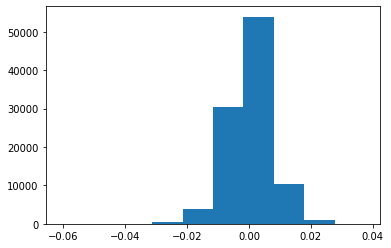

0.006941998287796105
0.00039704678688108467


In [ ]:
logincrements = xtrain[4:4+N]
hedge = np.zeros(Ktrain)
price = S0*np.ones((Ktrain,N))
for k in range(N-1):
    helper = logincrements[k][:,]
    helper = helper.transpose()
    price[:,k+1] = price[:,k]*np.exp(helper[:])
    hedge[:] = hedge[:] + scipy.norm.cdf((np.log(price[:,k]/strike)+0.5*(T-grid[k+1])*sigma**2)/(np.sqrt(T-grid[k+1])*sigma))*(price[:,k+1]-price[:,k])
hedge[:]= hedge[:]-0.5*(np.abs(price[:,N-1]-strike)+(price[:,N-1]-strike))+priceBS
plt.hist(hedge)
plt.show()
print(np.std(hedge))
print(np.mean(hedge))

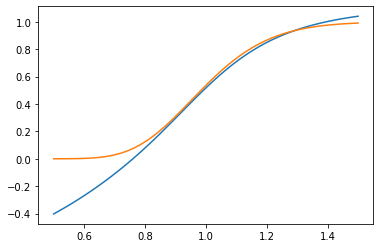

In [ ]:
l =20
s=np.linspace(0.5,1.5,Ktest)
z=scipy.norm.cdf((np.log(s/strike)+0.5*(T-grid[l])*sigma**2)/(np.sqrt(T-grid[l])*sigma))
#plt.plot(s,z)
#plt.plot(s,y)
y=model_hedge_strat.predict(xtest)[:,l]
plt.plot(s,y,s,z)
plt.show()

# Inverse Problems and training algorithms

# A simple example for conditional laws

Assume that we have a coin flipping experiment with a coin, chosen from a pool of coins, whose success probability is $p$. Let us consider $1$ as success and $0$ a fail. The law which determines $p$ has a density $\pi_0(p)$. Let us then flip the coin $k$ times with result $x_1,\ldots,x_k$. What is the probability law for $p$ given $x_1,\ldots,x_k$.

This a typical question for conditional distribution. We consider the random variables $X_1,\ldots,X_k$ which are Bernoulli distributed with success parameter $p$. Then
$$
P(X_1=x_1,\ldots,X_k=x_k|p) = p^{(x_1+\ldots+x_k)}(1-p)^{(k-(x_1+\ldots+x_k))}
$$
holds true. Bayes' theorem says
$$
P(p|x_1,\ldots,x_k)=\frac{p^{(x_1+\ldots+x_k)}(1-p)^{(k-(x_1+\ldots+x_k))}\pi_0(p)}{\int_0^1p^{(x_1+\ldots+x_k)}(1-p)^{(k-(x_1+\ldots+x_k))}\pi_0(p)dp} \, .
$$

In [ ]:
p0 = np.random.uniform(0,1,1)
def pi0(p):
    return 1

k=100
x = np.random.binomial(1,p0,k)
y = np.cumsum(x)
print(p0)
print(x)
print(y)

[0.37243277]
[1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0
 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1]
[ 1  1  1  1  2  3  4  4  4  4  4  4  5  5  5  5  5  5  6  7  8  9  9  9
 10 11 11 12 12 13 13 13 14 14 15 16 16 16 17 17 17 17 17 17 17 17 17 17
 18 18 18 18 18 18 18 19 20 20 21 21 21 21 21 21 22 22 22 23 24 24 25 26
 27 27 28 29 29 30 30 30 30 30 30 30 31 31 32 33 34 34 34 34 35 35 35 35
 35 35 35 36]


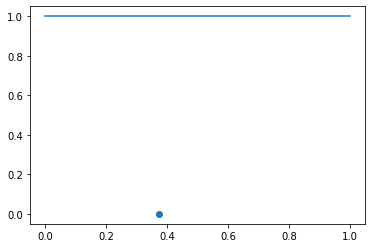

Prior mean 0.5


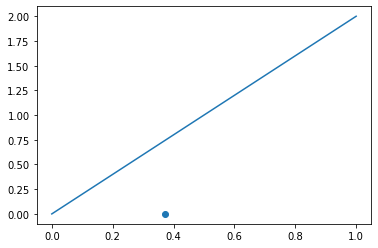

0.6670003336670003


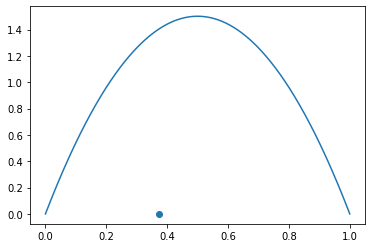

0.5


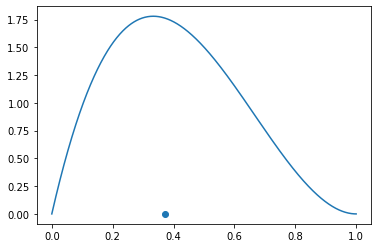

0.4000004008012016


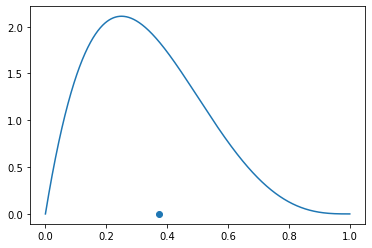

0.33333389000204067


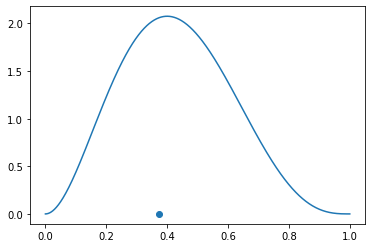

0.4285714285728628


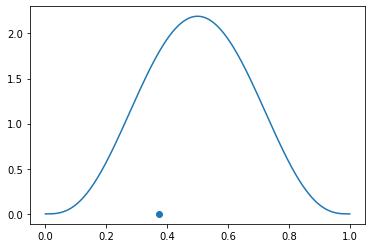

0.5000000000000001


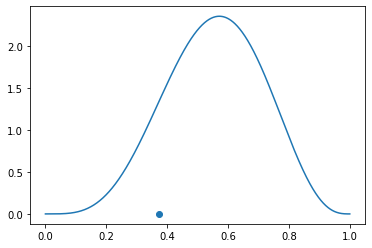

0.5555555555565966


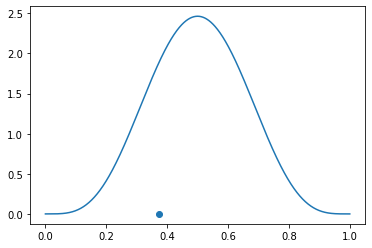

0.5


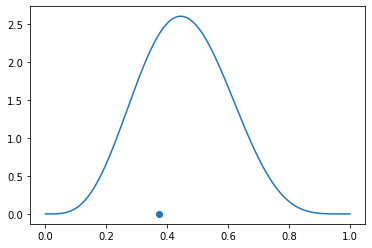

0.45454545454545453


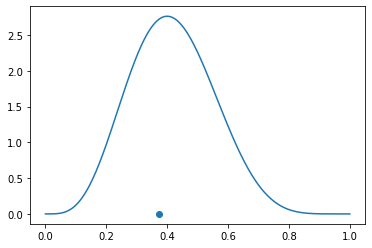

0.41666666666666663


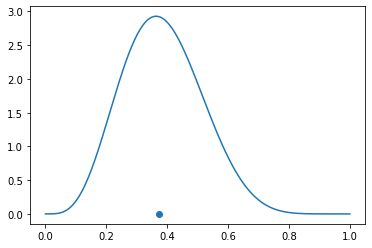

0.3846153846153845


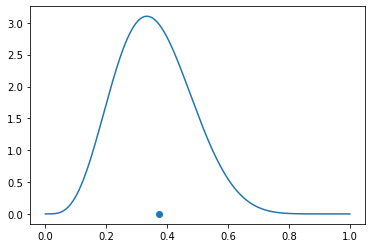

0.357142857142857


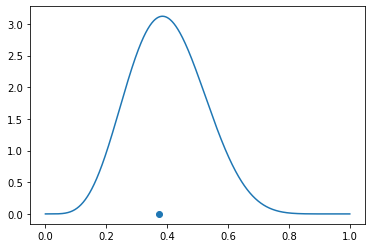

0.4000000000000001


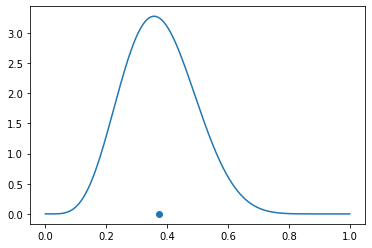

0.375


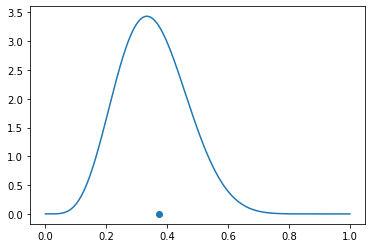

0.3529411764705883


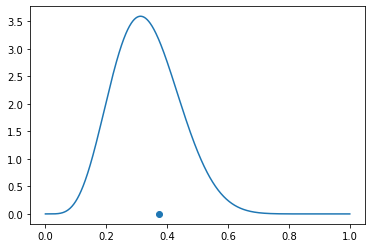

0.33333333333333337


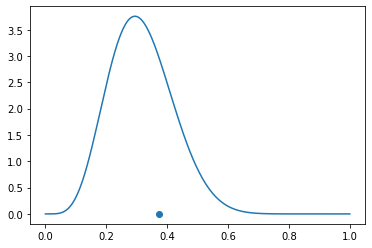

0.3157894736842106


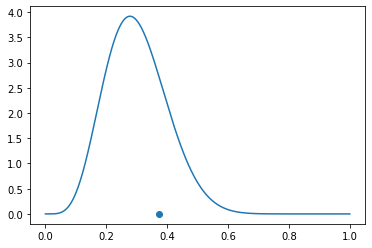

0.3000000000000002


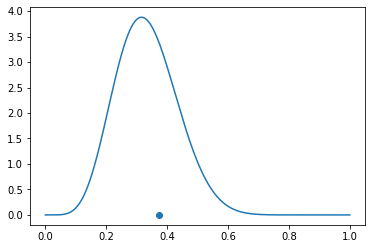

0.3333333333333333


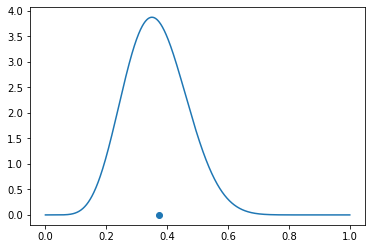

0.3636363636363637


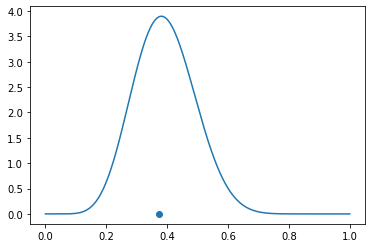

0.3913043478260869


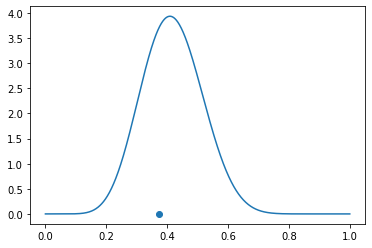

0.4166666666666667


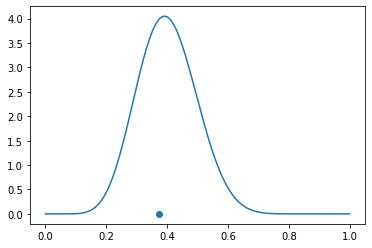

0.39999999999999997


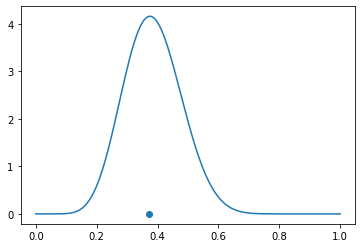

0.3846153846153846


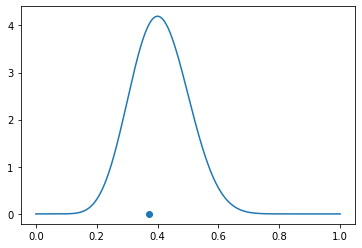

0.4074074074074074


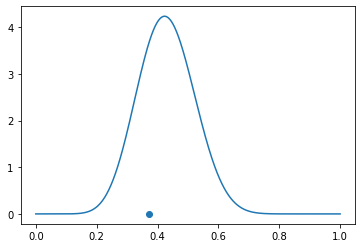

0.42857142857142866


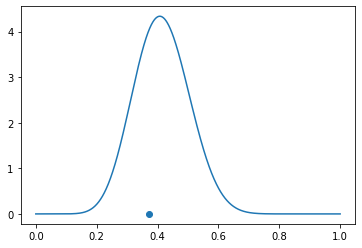

0.41379310344827586


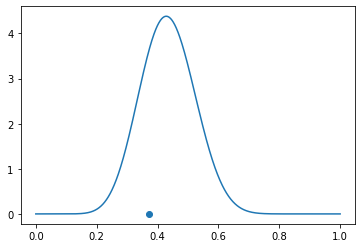

0.4333333333333333


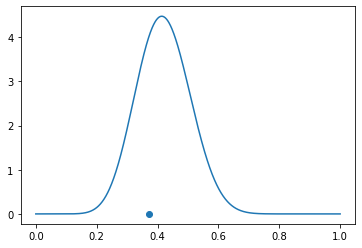

0.4193548387096775


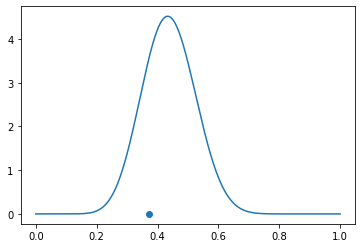

0.43749999999999994


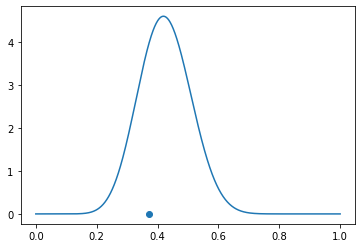

0.42424242424242425


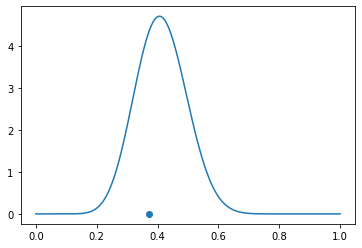

0.4117647058823529


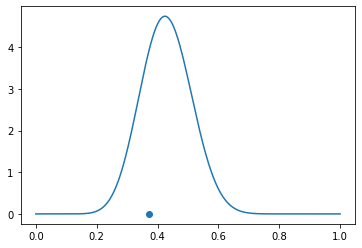

0.42857142857142855


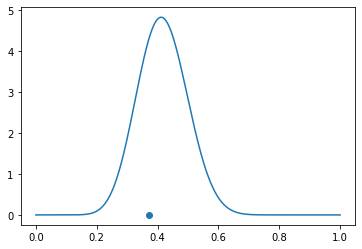

0.41666666666666663


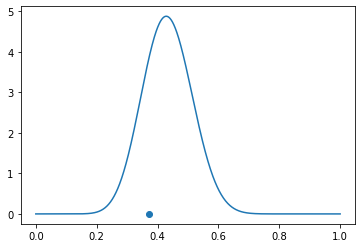

0.4324324324324324


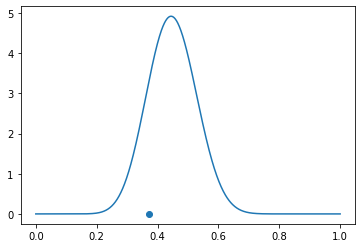

0.44736842105263164


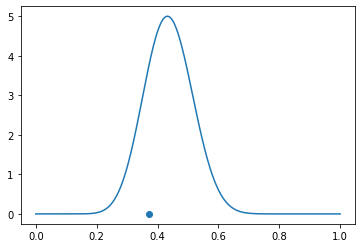

0.4358974358974359


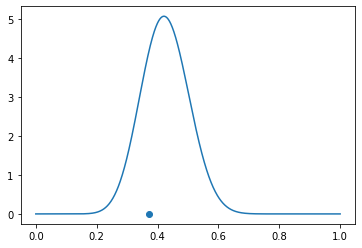

0.42500000000000004


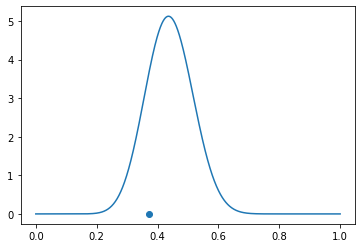

0.4390243902439024


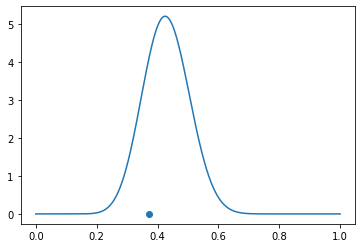

0.4285714285714286


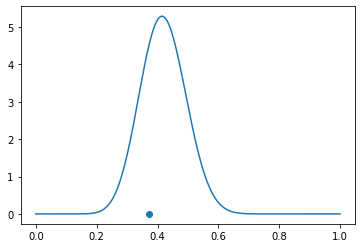

0.41860465116279066


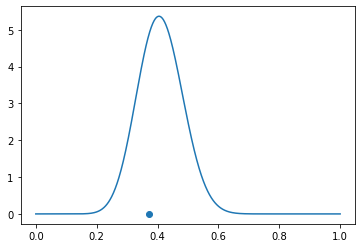

0.4090909090909091


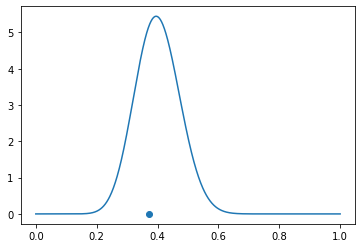

0.4000000000000001


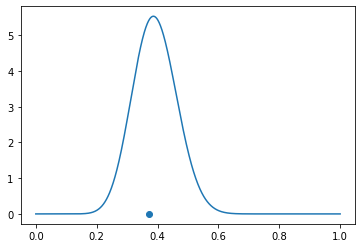

0.3913043478260869


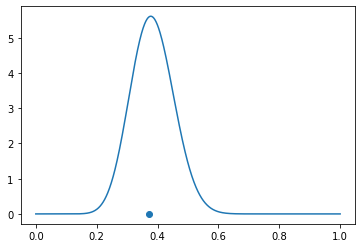

0.3829787234042553


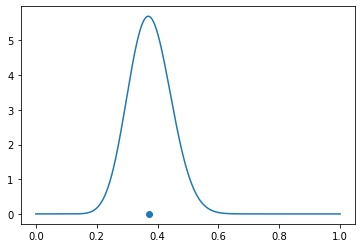

0.375


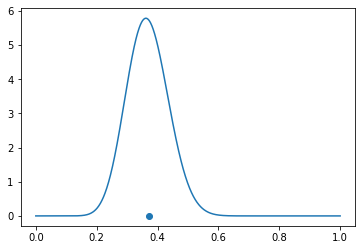

0.36734693877551033


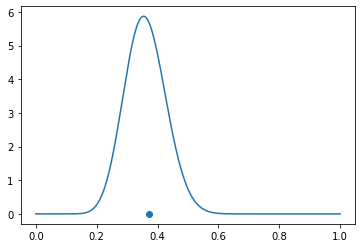

0.36


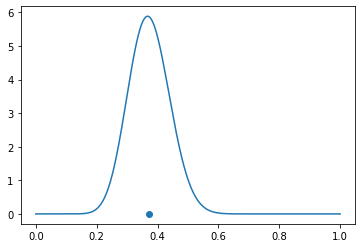

0.37254901960784315


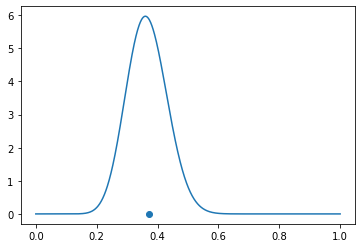

0.36538461538461536


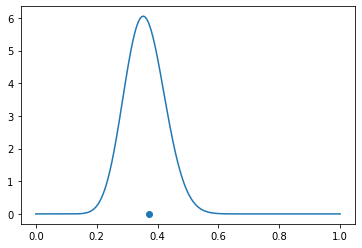

0.35849056603773577


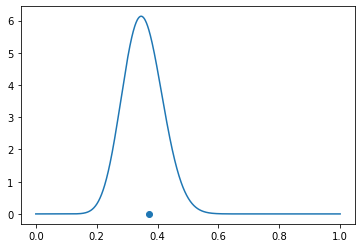

0.3518518518518519


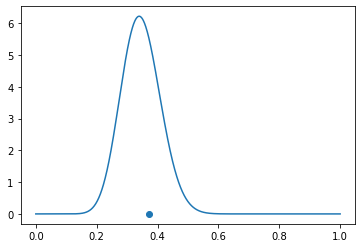

0.34545454545454546


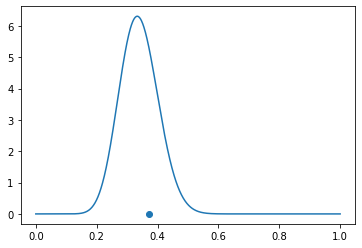

0.3392857142857143


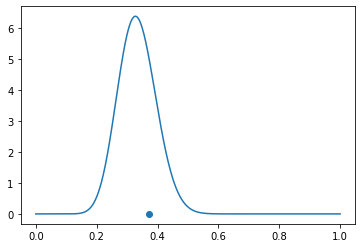

0.33333333333333337


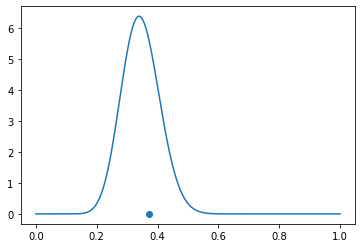

0.3448275862068966


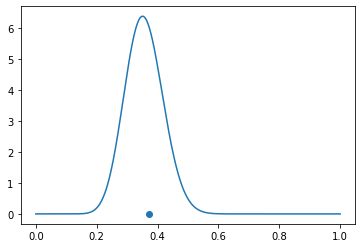

0.35593220338983056


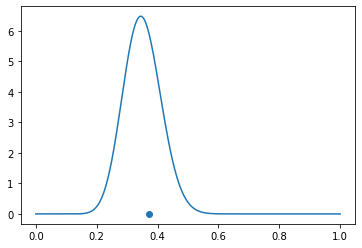

0.3499999999999999


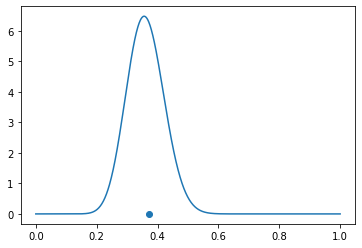

0.360655737704918


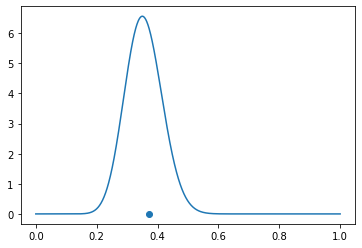

0.35483870967741926


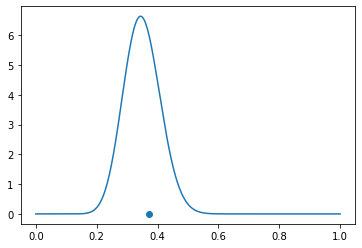

0.3492063492063492


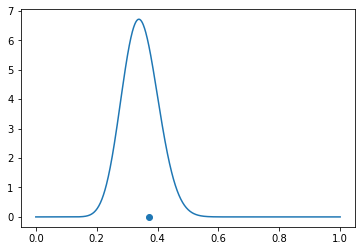

0.34375000000000006


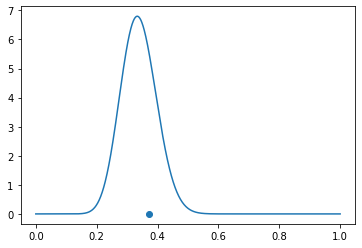

0.3384615384615385


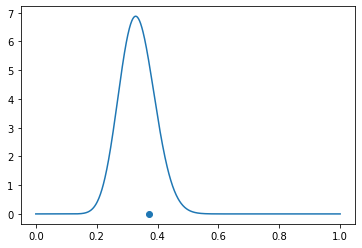

0.33333333333333337


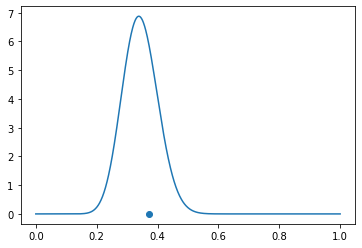

0.34328358208955234


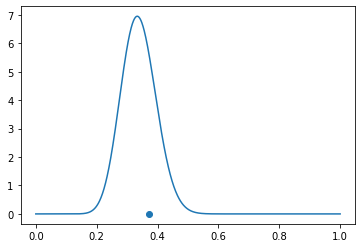

0.338235294117647


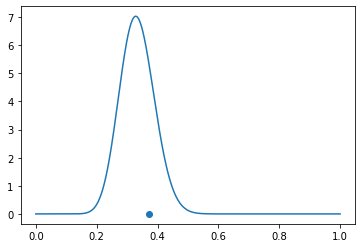

0.33333333333333337


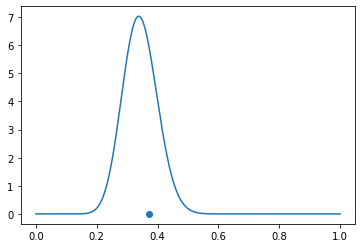

0.3428571428571429


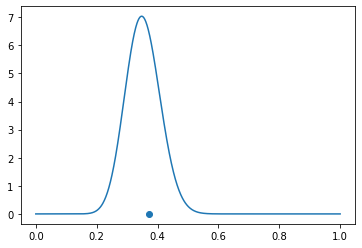

0.35211267605633806


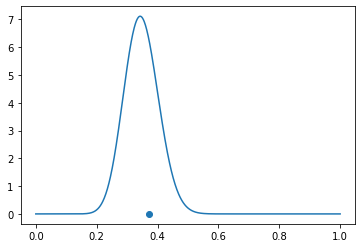

0.3472222222222222


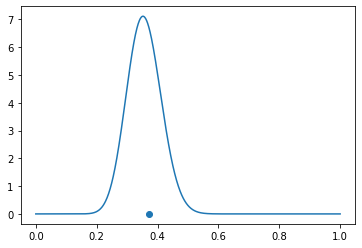

0.35616438356164387


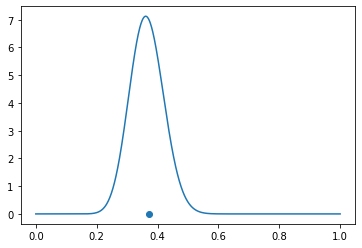

0.3648648648648649


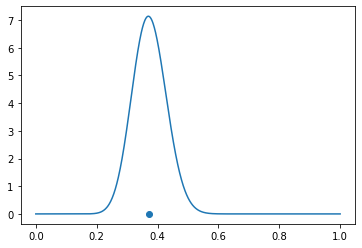

0.3733333333333333


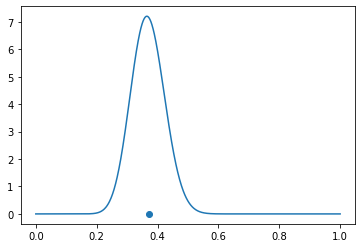

0.368421052631579


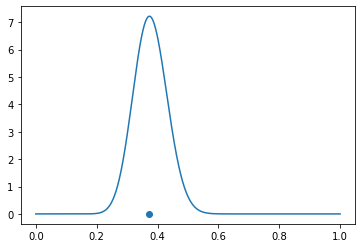

0.37662337662337664


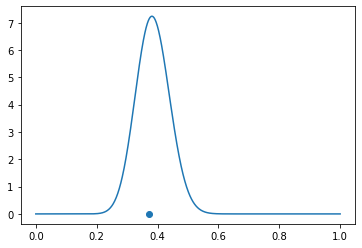

0.3846153846153846


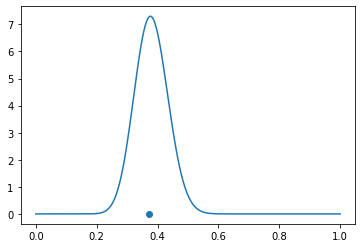

0.379746835443038


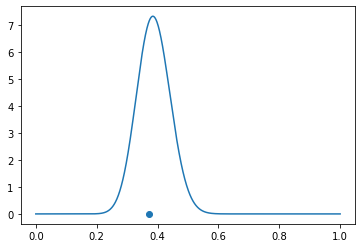

0.38749999999999996


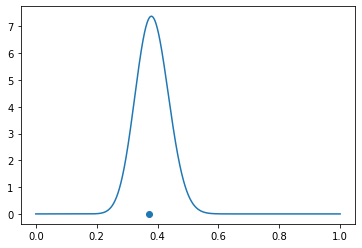

0.3827160493827161


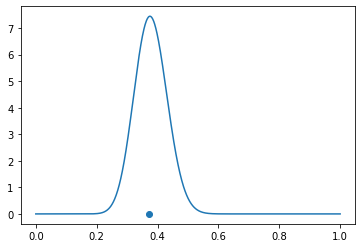

0.3780487804878048


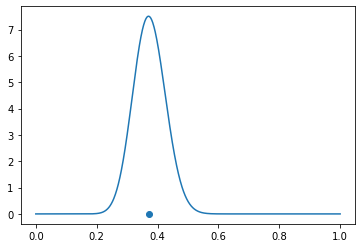

0.37349397590361444


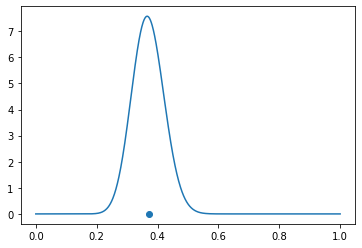

0.3690476190476191


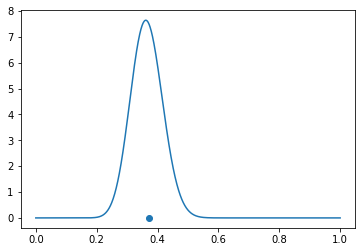

0.3647058823529412


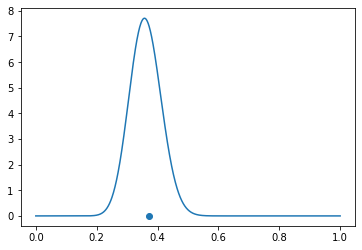

0.3604651162790698


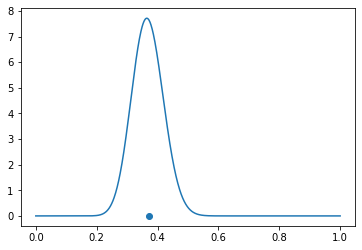

0.36781609195402304


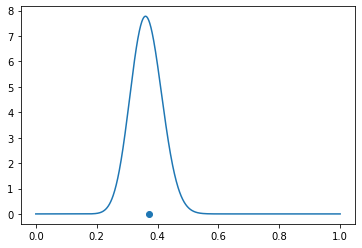

0.36363636363636365


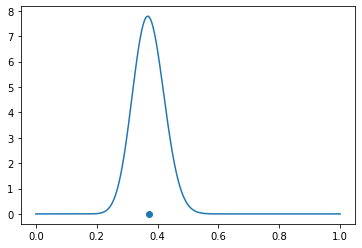

0.37078651685393255


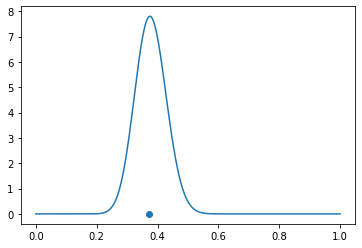

0.3777777777777778


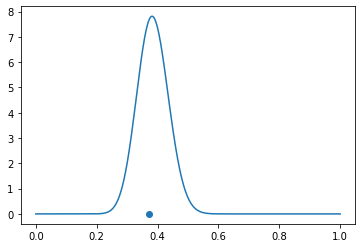

0.3846153846153846


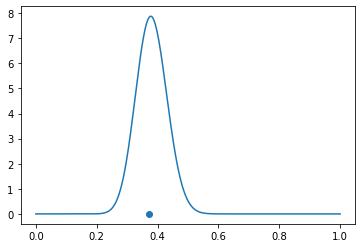

0.3804347826086957


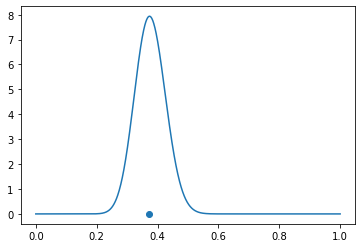

0.3763440860215054


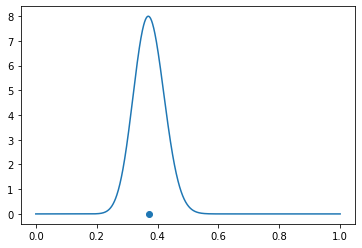

0.3723404255319149


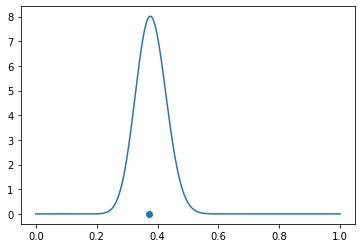

0.3789473684210526


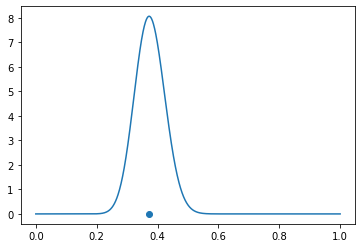

0.37499999999999994


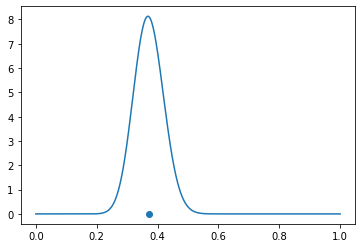

0.3711340206185567


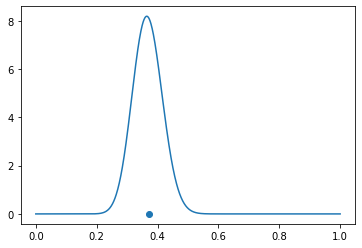

0.3673469387755102


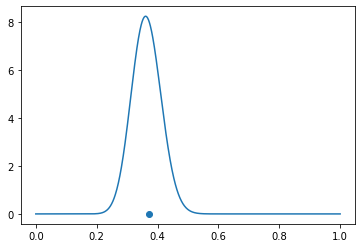

0.3636363636363637


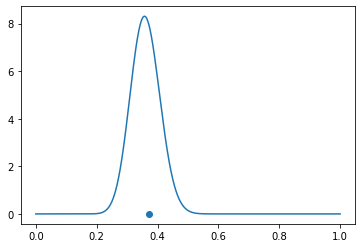

0.36


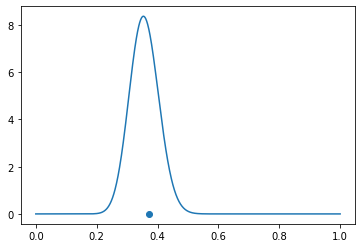

0.35643564356435636


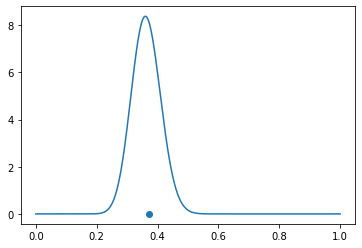

0.3627450980392156


In [ ]:
p = np.linspace(0,1,1000)
l = p**0*pi0(p)
l = l/np.sum(l)*1000
plt.plot(p,l)
plt.scatter(np.array([p0]),np.array([0]))
plt.show()
print('Prior mean', np.mean(l*p))

for i in range(k):
    p = np.linspace(0,1,1000)
    l = p**y[i]*(1-p)**(i+1-y[i])*pi0(p)
    l = l/np.sum(l)*1000
    plt.plot(p,l)
    plt.scatter(np.array([p0]),np.array([0]))
    plt.show()
    print(np.mean(l*p))

In the sequel we shall study inverse problems, where training appears as a particular instance of an inverse problem. We shall take the point of view of optimization problems but we shall always emphasize a Bayesian perspective on it.

We start with a very generic point of view: consider a non-negative measurable function $f$ on a probability space $ (\Theta,\pi_0) $, then calculating the essential supremum of $ f $ corresponds to calculating its $\infty$-norm, for which a well-known formula exists
$$
\lim_{n \to \infty} {|| f ||}_n = {||f||}_{\infty} \, .
$$
Let us first assume that $ f $ is essentially bounded a number $M>0$, then $ f/ {||f||}_{\infty} $ is essentially bounded by $1$ and we can without restriction assume that $ {||f||}_{\infty}= 1 $ (with respect to the measure $ \pi_0$). Let $ 0 < \epsilon < 1 $ be fixed, then $ \pi_0[\{f > 1-\epsilon \}] > 0 $, hence
$$
{|| f ||}_n \geq (1-\epsilon) {(\pi_0[\{f > 1 - \epsilon \}])}^{1/n} \, ,
$$
whence for all $ n $ large enough greater than, say, $ 1 - 2 \epsilon $. Since $ \epsilon $ was arbitrary, this yields the proof.
If $ f $ is unbounded, then $ \pi_0[\{f > k \}] > 0 $ for all $ k $, hence
$$
{|| f ||}_n \geq k {(\pi_0[\{f > k \}])}^{1/n} \, .
$$
So we can find for every $ k $ a number $ n_k $ such that the right hand side is large than $ k/2 $, and we conclude again.

We can interpret this equality in the case $ f = \exp(-L) $ for a finite measurable function $L$ and obtain immediately
$$
\operatorname{ess-inf}_{\theta \in \Theta} L(\theta) = - \lim_{n \to \infty} \frac{1}{n} \log \Big( \int \exp \big(- n L(\theta) \big) \pi_0(d\theta) \Big) \; \; \;  {\mathrm (EQ)} \, .
$$
Assume additionally that $ L $ is bounded from below. Then we expect the integrand to concentrate at arguments where values close to infima are taken, in other words it is worth investigating the probability measure
$$
\pi_n (d \theta) := \frac{\exp \big(-n L(\theta) \big) \pi_0(d\theta)}{\int \exp \big(- n L(\theta) \big) \pi_0(d\theta)} \, .
$$
Concentration around arguments where values close to infima are taken can be interpreted by proving that
$$
\lim_{n \to \infty} \pi_n [A] = 0
$$
for all measurable sets $ A $ such that there exists $ \epsilon > 0 $ and $ L(\theta) > \operatorname{ess-inf}_{\theta \in \Theta} L(\theta) + \epsilon $ for $ \theta \in A $. This in turn is equivalent to proving that
$$
\frac{\int_A \exp \big(- n L(\theta) \big) \pi_0(d\theta)}{\int \exp \big(- n L(\theta) \big) \pi_0(d\theta)} \rightarrow_{n \to \infty} 0 \, ,
$$
for such $A$, which follows immediately from equation $ \mathrm (EQ) $. Indeed, we obtain
$$
-\frac{1}{n} \log \Big(\int_A \exp \big(- n L(\theta) \big) \pi_0(d\theta) \Big) \geq \operatorname{ess-inf}_{\theta \in \Theta} L(\theta) + \epsilon
$$
for all $ n $, whence for all $ n $ large enough
$$
-\frac{1}{n} \log \frac{\int_A \exp \big(- n L(\theta) \big) \pi_0(d\theta)}{\int \exp \big(- n L(\theta) \big) \pi_0(d\theta)} \geq \epsilon/2
$$
holds true. This means that the limit of the term inside the logarithm has to vanish as $n$ goes to infinity.

Summing up this yields the following statement: for a measurable function $L$ essentially bounded from below the measure $ \pi_n $ concentrates at arguments where values close to the infimum are taken. This statement has a Bayesian interpretation. Consider $ \pi_0 $ as prior on $ \Theta $ and consider $ L $ a (negative) log-likelihood, then $ \pi_1 $ is the posterior calculated by Bayes formula (when do not have data in the moment), $ \pi_n $ appears as interation of this procedure and concentrates at arguments for the likelihood maximizes.

Let us introduce data in the next step, i.e. we consider the function $L$ as a measurable function of two variables $ z $, the data, and $ \theta $, the parameter, on a product space $ Z \times \Theta $, where $ Z $ only has a measurable structure. We shall write $L^z := L(z,.) $ and assume this function to be bounded from below and measurable. Then we can apply the previous considerations in a data-dependent way.

As a remark we add: for fixed $ \theta \in \Theta $ we can sometimes view $ z \mapsto \exp(-L^z(\theta)) $ as density of a random variable $Z$ with respect to some reference measure $ \nu $ on $Z$. In this case the fully Bayesian interpretation takes place, but actually we do not need this here.

A parameter-dependent optimization problem is an inverse problem: we are interested in describing a map
$$
z \mapsto \theta^*(z) \in \operatorname{arginf}_{\theta \in \Theta} L^z(\theta)
$$
for some $ z \in Z $. We give ourselves additionally topologies on $ Z $ and $ \Theta $ with corresponding sigma algebras being the Borel sigma algebras. We can require, following [Jacques Hadamard](https://en.wikipedia.org/wiki/Jacques_Hadamard), the following properties of such a map:
1. Existence for a large subset of $Z$.
2. Uniqueness for a large subset of $Z$.
3. Stability where it is uniquely defined, i.e. continuity as a map from $Z$ to $\Theta$.

Usually it is delicate to guarantee the three properties, which, however, are important if $z \in Z $ are considered data and $ \theta^*(z) \in \Theta $ a selected model (identifified by a parameter). Often those properties can be achieved if the problem is replaced by a regularized problem by adding a regularization term $ P: \Theta \to \mathbb{R}_{>0} $, i.e. we consider
$$
\operatorname{inf}_{\theta \in \Theta} L^z(\theta) + \lambda P(\theta) \, ,
$$
where $ \lambda > 0 $ is an additional parameter.

This by now classical theory has been developed in many directions, we shall compare it here with the above developed Bayesian perspective. Consider a reference measure $ \nu $ on $ \Theta $ and define a prior
$$
\pi_0 (d \theta) = \frac{\exp(- \lambda P(\theta)) \nu (d \theta)}{\int \exp(- \lambda P(\theta)) \nu (d \theta)} \, .
$$
Then the posterior
$$
\pi_n (d \theta) = \frac{\exp(- n L^z(\theta) - \lambda P(\theta)) \nu (d \theta)}{\int \exp(-n L^z(\theta) - \lambda P(\theta)) \nu (d \theta)}
$$
can be considered a generalized solution of the inverse problem (depending on parmaters $n$ and $\lambda$), which concentrates at arguments, where values of $L^z+\frac{\lambda}{n}P$ are close it their infimum. Notice that it is relatively easy to guarantee that $\pi_n$ depends continously on $ z $.

We do not go into detail which regularization functionals $P$ have to be chosen to guarantee Hadamard's properties, or under which assumptions the Bayesian solution satisfies them. We just want to point out that solving the optimization problem
$$
z \mapsto \theta^*(z) \in \operatorname{arginf}_{\theta \in \Theta} L^z(\theta)
$$
has to be either regularized or interpreted in a Bayesian way to provide useful solutions. We shall see in the sequel that the Bayesian interpretation is related to certain simulation alogrithms of gradient descent type.

# Training

The most enigmatic procedure in machine learning is training of neural networks, or, in general, parametric families of functions. This is of course an inverse problem, on which we have developed two perspectives above: the optimization perspective (with regularization) and the Bayesian perspective.

Essentially training is described as minimization of loss, i.e. for a given loss function $ L $ on a space of functions $ f $ parametrized by a set of parameters $ \theta \in \Theta $
$$
\operatorname{arginf}_{\theta \in \Theta} L(f^\theta)
$$
is searched.

Assume that $ \Theta $ is some open subset of points in $ \mathbb{R}^d $ and $ U : \Theta \to \mathbb{R} $, $ \theta \mapsto L(f^\theta) $ a sufficiently regular function with a unique minimum $ \theta^* \in \Theta $, then one can describe essentially one local and one global method to find the infimum:

1. If $ U $ is strictly convex and $ C^2 $ in a neighborhood of the unique minimizer $ \theta^* $, then
$$
d \theta_t = - \nabla_\Theta U(\theta_t) dt
$$
converges to $ \theta^* $ as $ t \to \infty $. For any $ t \geq 0 $ it holds that
$$
d U(\theta_t) = - {|| \nabla U(\theta_t) ||}^2 dt \, ,
$$
i.e. the value of $ U $ is strictly increasing along the path $ t \mapsto \theta_t $. Together with the fact that $ U $ is strictly convex we obtain a convergence of $ || \theta_ t - \theta^* || \leq C \exp(- \lambda_{\text{min}} t ) $ as $ t \to \infty $, where $ \lambda_{\mathrm min} $ is the minimum of the smallest eigenvalue of the Hessian of $ U $ on $ \Theta $. This holds remarkably for any starting point $ \theta_0 \in \Theta $ and is the basis of all sorts of gradient descent algorithms.

2. A far reaching generalization is given by the following consideration: consider $ U $ on $ \Theta $ having a unique minimizer $ \theta^* \in \Theta $, then the probability measure given by the density with respect to Lebesgue measure on $ \mathbb{R}^d$
$$
p_\epsilon := \frac{1}{Z_\epsilon} \exp \big( -\frac{U}{\epsilon} \big)
$$
tends in law to $ \delta_{\theta^*} $ as $ \epsilon \to 0 $. The denominator $ Z_\epsilon $ is just the integral $ \int_{\Theta} \exp(-U(\theta)/\epsilon) d \lambda(\theta)  $ and the above statement nothing else than the fact that the described density function concentrates at $ \theta^* $. If one manages to sample from the measure $ p_\epsilon d \lambda $, then one can approximate empirically $ \theta^* $.

The measure $ p_\epsilon d \lambda $ is the invariant measure of the stochastic differential equation
$$
d \theta_t = - \frac{1}{2} \nabla U(\theta_t) dt + \sqrt{\epsilon} dW_t \, ,
$$
which is just checked by the following equality
$$
\int_{\Theta} \big ( - \frac{1}{2} \nabla U(\theta) \nabla f(\theta) + \frac{\epsilon}{2} \Delta f(\theta) \big) p_\epsilon (\theta) d \lambda (\theta) = 0
$$
for all test functions $ f $.

One method, which generalizes this thought in a time-dependent way, is to sample from a measure concentrating at $\theta^*$ is to simulate from a stochastic differential equation (for $ \Theta = \mathbb{R}^N $) of the type
$$
d \theta_t = - \nabla U(\theta_t) dt + \alpha(t) dW_t
$$
where $ W $ is an $ N $-dimensional Brownian motion and the non-negative quantity, called cooling schedule, $ \alpha(t) = O(\frac{1}{\log(t)}) $ as $ t \to \infty $. For appropriate constants we obtain that $ \theta_t $ converges in law to $ \delta_{\theta^*} $ as $ t \to \infty $. This procedure is called simulated annealing and is the fundament for global mimimization algorithms of the type 'steepest descent plus noise'.

In machine learning applications, however, an algorithm, which traces back to work of Robbins-Monro (Kiefer-Wolfowitz respectively) in the fifties of the last century, is applied, the so called [stochastic approximation algorithm](https://en.wikipedia.org/wiki/Stochastic_approximation).

The stochastic gradient descent algorithm essentially says for a function of expectation type $ U(\theta) = E \big[ V(\theta) \big] $
$$
\theta_{n+1} = \theta_n - \gamma_n \nabla V(\theta_n,\omega_n)
$$
for independently chosen samples $ \omega_n $ converges in law to $ \theta^* $. Notice first that all our examples, in particular the ones from mathematical finance, are of expectation type, where the samples $ \omega $ are usually seen as elements from the training data set.

There are several proofs of this statement, but I want to focus one particular aspect which connects stochastic approximation with simulated annealing.

By the central limit theorem and appropriate sub-sampling one can understand
$$
\nabla V(\theta,\omega) = \nabla U(\theta) + \text{ 'Gaussian noise with a certain covariance structure' } \Sigma(\theta)
$$
where $ \Sigma(\theta) $ is essentially given by
$$
\operatorname{cov}(\nabla V(\theta)) \, .
$$
Whence one can understand stochastic gradient descent as simulated annealing with a space dependent covariance structure.

Such simulated annealing algorithms exist but are more sophisticated in nature, in particular one needs to work with geometric structures on $ \Theta $.